<a href="https://colab.research.google.com/github/anigan27/Brain-Tumor-Classification/blob/main/github_GT_transfer_learning_and_image_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from os import mkdir
import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from numpy import expand_dims


In [ ]:
#loading dataset to colab
# the link with how to load the dataset from kaggle to colab
#https://www.geeksforgeeks.org/how-to-import-kaggle-datasets-directly-into-google-colab/
!pip install kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri
!unzip brain-tumor-classification-mri

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
 84% 73.0M/86.8M [00:00<00:00, 148MB/s]
100% 86.8M/86.8M [00:00<00:00, 146MB/s]
Archive:  brain-tumor-classification-mri.zip
  inflating: Testing/glioma_tumor/image(1).jpg  
  inflating: Testing/glioma_tumor/image(10).jpg  
  inflating: Testing/glioma_tumor/image(100).jpg  
  inflating: Testing/glioma_tumor/image(11).jpg  
  inflating: Testing/glioma_tumor/image(12).jpg  
  inflating: Testing/glioma_tumor/image(13).jpg  
  inflating: Testing/glioma_tumor/image(14).jpg  
  inflating: Testing/glioma_tumor/image(15).jpg  
  inflating: Testing/glioma_tumor/image(16).jpg  
  inflating: Testing/glioma_tumor/image(17).jpg  
  inflating: Testing/glioma_tumor/image(18).jpg  
  inflating: Testing/glioma_tumor/image(19).jpg  
  inflating: Testing/glioma_tumor/im

In [ ]:
train_directory = '/content/Training'
test_directory = '/content/Testing'
categories = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
image_size = 256

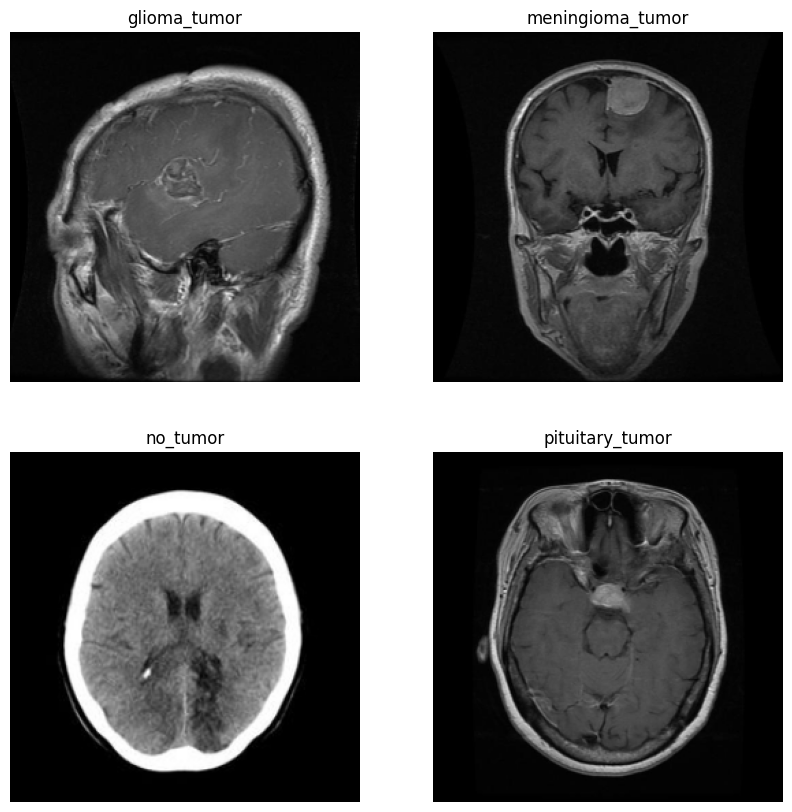

In [ ]:
import os
tumor_data = []
tumor_labels = []
plt.figure(figsize=(10, 10))
for label in range(len(categories)):
    class_name = categories[label]
    class_path = os.path.join(train_directory, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image = cv2.imread(image_path)
        if image is not None:
            image_resized = cv2.resize(image, (image_size, image_size))
            tumor_data.append(image_resized)
            tumor_labels.append(label)
    plt.subplot(2, 2, label + 1)
    plt.axis('off')
    plt.title(class_name)
    plt.imshow(image_resized)
plt.show()


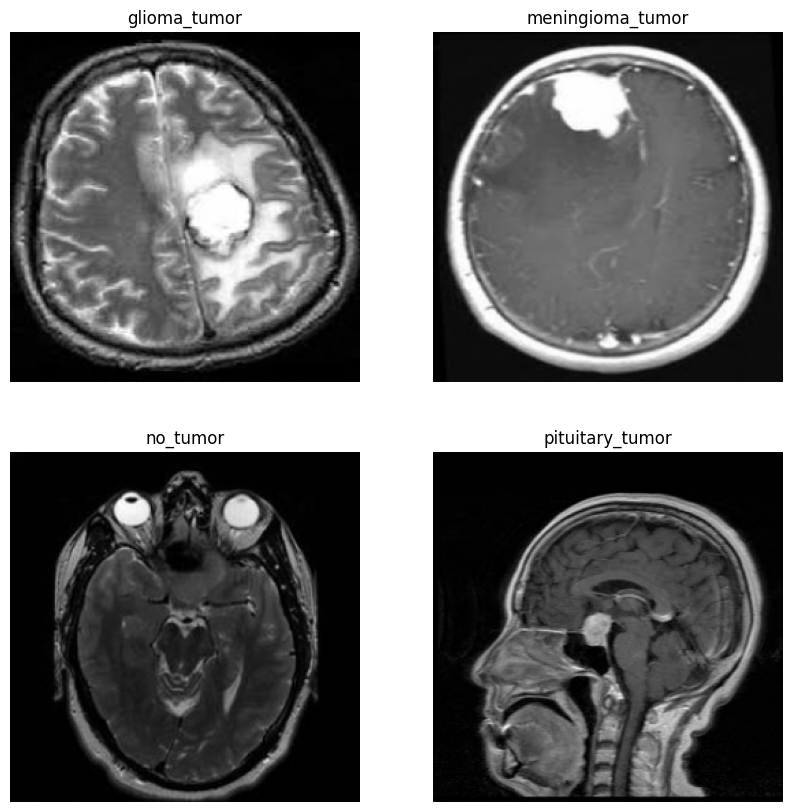

In [ ]:
import os
tumor_test_data = []
tumor_test_labels = []
plt.figure(figsize=(10, 10))
for label in range(len(categories)):
    class_name = categories[label]
    class_path = os.path.join(test_directory, class_name)
    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)
        image = cv2.imread(image_path)
        if image is not None:
            image_resized = cv2.resize(image, (image_size, image_size))
            tumor_test_data.append(image_resized)
            tumor_test_labels.append(label)
    plt.subplot(2, 2, label + 1)
    plt.axis('off')
    plt.title(class_name)
    plt.imshow(image_resized)
plt.show()


In [ ]:
np.save("/content/tumor_data", tumor_data, allow_pickle=True, fix_imports=True)
np.save("/content/labels", tumor_labels, allow_pickle=True, fix_imports=True)
np.save("/content/tumor_test_data", tumor_test_data, allow_pickle=True, fix_imports=True)
np.save("/content/tumor_test_labels", tumor_test_labels, allow_pickle=True, fix_imports=True)

In [ ]:
brain_images = np.load("/content/tumor_data.npy")
labels = np.load("/content/labels.npy")
brain_images_test = np.load("/content/tumor_test_data.npy")
labels_test = np.load("/content/tumor_test_labels.npy")

In [ ]:
def normalize_one_image(image):
  """
    This function takes in an image and returns a new image normalized on a 0 to 1 scale
  """
  image_normalized = image.copy()
  image_normalized = image.astype('float32')
  min_val = np.min(image_normalized)
  max_val = np.max(image_normalized)
  image_normalized = (image_normalized - min_val) / (max_val - min_val)
  return image_normalized

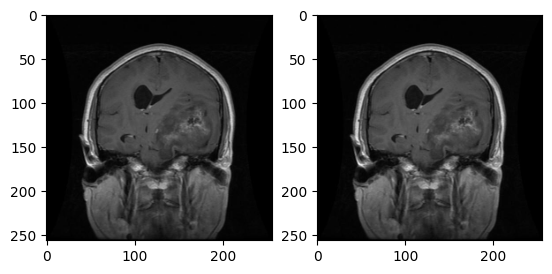

In [ ]:
#normalize all images
normalized_brain_images = np.array([normalize_one_image(image) for image in brain_images])
plt.subplot(1, 2, 1)
plt.imshow(brain_images[10])
plt.subplot(1, 2, 2)
plt.imshow(normalized_brain_images[10])
normalized_test_images = np.array([normalize_one_image(image) for image in brain_images_test])

In [ ]:
#testing how to augment images with multiple layers
import tensorflow as tf
from tensorflow.keras import layers

data_flip = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical")
])

data_rotate = tf.keras.Sequential([
  layers.RandomRotation(0.2)
])


data_contrast = tf.keras.Sequential([
  layers.RandomContrast(0.9)
])

In [ ]:
#horizontal and vertical flip, random contrast, and random rotate the images in brain_image while retaining the labels


augmented_brain_images_flip = np.array([data_flip(image) for image in normalized_brain_images])
augmented_brain_labels_flip = np.array([labels[i] for i in range(len(labels))])

# Use np.concatenate to join the arrays
brain_images = np.concatenate((brain_images, augmented_brain_images_flip), axis=0)
labels = np.concatenate((labels, augmented_brain_labels_flip), axis=0)

augmented_brain_images_contrast = np.array([data_contrast(image) for image in normalized_brain_images])
brain_images = np.concatenate((brain_images, augmented_brain_images_contrast), axis=0)
labels = np.concatenate((labels, augmented_brain_labels_flip), axis=0)

augmented_brain_images_rotate = np.array([data_rotate(image) for image in normalized_brain_images])
brain_images = np.concatenate((brain_images, augmented_brain_images_rotate), axis=0)
labels = np.concatenate((labels, augmented_brain_labels_flip), axis=0)

brain_images.shape


(11480, 256, 256, 3)

In [ ]:
X_train = np.array(brain_images)
y_train = np.array(labels)
X_test = np.array(brain_images_test)
y_test = np.array(labels_test)


#CNN


In [ ]:
#CNN architecture
import tensorflow as tf
from keras.models import Sequential
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from keras.layers import Conv2D, BatchNormalization, Dense, RandomFlip, RandomTranslation, RandomRotation, GlobalAveragePooling2D, Input, RandomZoom, Rescaling, MaxPooling2D, Flatten

class_name = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
model = Sequential([
    Input(shape=(image_size, image_size, 3), batch_size=32),

    #Rescaling(1./255.),
    #RandomFlip('horizontal'),
    RandomRotation(0.2),
    #RandomZoom(0.2),
    #RandomTranslation(height_factor=0.25,width_factor=0.25, fill_mode='reflect', interpolation='bilinear'),

    Conv2D(filters=32, kernel_size=(3,3), activation='relu', name='Conv2D_1'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(filters=64, kernel_size=(3,3), activation='relu', name='Conv2D_2'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Conv2D(filters=128, kernel_size=(3,3), activation='relu', name='Conv2D_3'),
    BatchNormalization(),
    MaxPooling2D((2,2)),


    #GlobalAveragePooling2D(),
    Flatten(),


    Dense(units=128, activation='relu'),
    BatchNormalization(),

    Dense(units=len(class_name), activation='softmax')

])

ES = EarlyStopping(monitor='val_accuracy', patience=10, verbose=2, restore_best_weights=True, mode='max', min_delta=0)
MP = ModelCheckpoint(filepath='Best_model.keras', monitor='val_accuracy', verbose=2, save_best_only=True, mode='max')
RP = ReduceLROnPlateau(monitor='val_loss', patience=5, verbose=2, min_lr=0.0001, factor=0.2)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])
model.summary()

y_train = to_categorical(y_train)


history = model.fit(X_train,y_train,validation_split=0.15, epochs =14, verbose=1, batch_size=10,
                   callbacks=[ES,MP,RP])


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_rotation_1 (RandomRotation)   │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2D_1 (Conv2D)                    │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (32, 254, 254, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2D_2 (Conv2D)                    │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (32, 125, 125, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Conv2D_3 (Conv2D)                    │ (32, 60, 60, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (32, 60, 60, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (32, 30, 30, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 115200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (32, 128)                   │      14,745,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (32, 128)                   │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (32, 4)                     │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,840,900 (56.61 MB)

 Trainable params: 14,840,196 (56.61 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/14
976/976 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4382 - loss: 1.4038 - precision: 0.5070 - recall: 0.2164
Epoch 1: val_accuracy improved from -inf to 0.28978, saving model to Best_model.keras
976/976 ━━━━━━━━━━━━━━━━━━━━ 30s 24ms/step - accuracy: 0.4382 - loss: 1.4036 - precision: 0.5070 - recall: 0.2164 - val_accuracy: 0.2898 - val_loss: 1.2905 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/14
976/976 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4778 - loss: 1.1773 - precision: 0.5927 - recall: 0.2171
Epoch 2: val_accuracy did not improve from 0.28978
976/976 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.4778 - loss: 1.1773 - precision: 0.5928 - recall: 0.2171 - val_accuracy: 0.2294 - val_loss: 1.1754 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/14
976/976 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4776 - loss: 1.1593 - precision: 0.5980 - recall: 0.2267
Epoch 3: val_accuracy imp

In [ ]:

predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)
actual_labels = y_test



13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(actual_labels, predictions, target_names=class_name))

                  precision    recall  f1-score   support

    glioma_tumor       0.00      0.00      0.00       100
meningioma_tumor       0.34      0.62      0.44       115
        no_tumor       0.38      0.38      0.38       105
 pituitary_tumor       0.45      0.49      0.47        74

        accuracy                           0.37       394
       macro avg       0.29      0.37      0.32       394
    weighted avg       0.29      0.37      0.32       394



Text(50.58159722222221, 0.5, 'Actual')

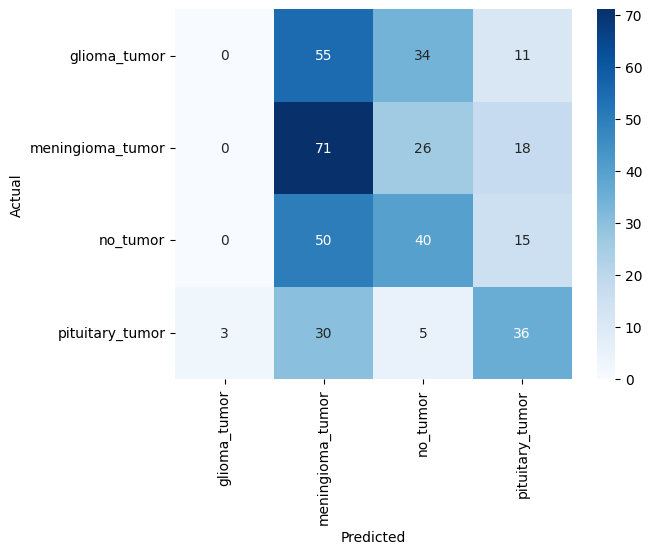

In [ ]:
#make a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(actual_labels, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_name, yticklabels=class_name)
plt.xlabel('Predicted')
plt.ylabel('Actual')

#Effnet

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from sklearn.metrics import classification_report,confusion_matrix
effnet = EfficientNetB0(weights='imagenet',include_top=False,input_shape=(image_size,image_size,3))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = effnet.output
model = tf.keras.layers.GlobalAveragePooling2D()(model)
model = tf.keras.layers.Dropout(rate=0.5)(model)
model = tf.keras.layers.Dense(4,activation='softmax')(model)
model = tf.keras.models.Model(inputs=effnet.input, outputs = model)

In [ ]:
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 256, 256, 3)    │              0 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 256, 256, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 256, 256, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 257, 257, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 128, 128, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 128, 128, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 128, 128, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 128, 128, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 128, 128, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 128, 128, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 4,012,672 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer = 'Adam', metrics= ['accuracy'])

In [ ]:
tensorboard = TensorBoard(log_dir = 'logs')
checkpoint = ModelCheckpoint("effnet.keras",monitor="val_accuracy",save_best_only=True,mode="auto",verbose=1)
reduce_lr = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.3, patience = 2, min_delta = 0.001,
                              mode='auto',verbose=1)

In [ ]:
y_train = np.array(labels)
y_train=to_categorical(y_train)
history = model.fit(X_train,y_train,validation_split=0.1, epochs =12, verbose=1, batch_size=32,
                   callbacks=[tensorboard,checkpoint,reduce_lr])

Epoch 1/12
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.6782 - loss: 0.7629
Epoch 1: val_accuracy improved from -inf to 0.27700, saving model to effnet.keras
323/323 ━━━━━━━━━━━━━━━━━━━━ 142s 210ms/step - accuracy: 0.6785 - loss: 0.7622 - val_accuracy: 0.2770 - val_loss: 1.7896 - learning_rate: 0.0010
Epoch 2/12
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9231 - loss: 0.1961
Epoch 2: val_accuracy did not improve from 0.27700
323/323 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.9231 - loss: 0.1961 - val_accuracy: 0.2770 - val_loss: 3.1606 - learning_rate: 0.0010
Epoch 3/12
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9528 - loss: 0.1286
Epoch 3: val_accuracy improved from 0.27700 to 0.32230, saving model to effnet.keras
323/323 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.9528 - loss: 0.1285 - val_accuracy: 0.3223 - val_loss: 1.9803 - learning_rate: 0.0010
Epoch 4/12
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9695 - loss: 0.0910
Ep

In [ ]:
class_name = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
predictions = model.predict(normalized_test_images)
predictions = np.argmax(predictions, axis=1)
actual_labels = labels_test

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 692ms/step


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(actual_labels, predictions, target_names=class_name))

                  precision    recall  f1-score   support

    glioma_tumor       0.94      0.31      0.47       100
meningioma_tumor       0.75      0.96      0.84       115
        no_tumor       0.73      1.00      0.84       105
 pituitary_tumor       0.91      0.86      0.89        74

        accuracy                           0.79       394
       macro avg       0.83      0.78      0.76       394
    weighted avg       0.82      0.79      0.76       394



Text(50.58159722222221, 0.5, 'Actual')

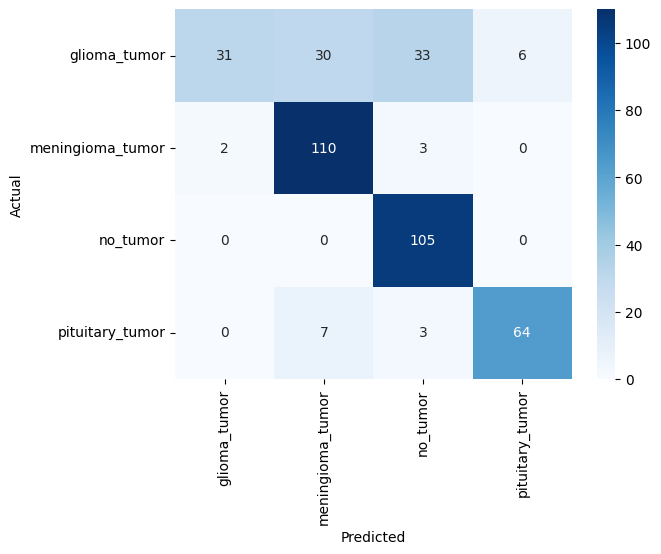

In [ ]:

cm = confusion_matrix(actual_labels,predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_name, yticklabels=class_name)
plt.xlabel('Predicted')
plt.ylabel('Actual')
